# Regresyon ve Sınıflandırma Modelleri
**Kutay Kalay** · SoftITo Yapay Zeka · 22.09.2026

1. **Regresyon:** California ev fiyatları (çoklu doğrusal regresyon, OLS özeti, artık analizi, polinom regresyon)
2. **Sınıflandırma:** German Credit kredi riski (Lojistik regresyon, SVM, KNN, GridSearch, karşılaştırma)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.datasets import fetch_california_housing, fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay, RocCurveDisplay)

SEED = 42
sns.set_theme(style="whitegrid")

## 1. Regresyon: California ev fiyatları
**Hedef:** `MedHouseVal`, bölgedeki medyan ev değeri (100.000 $ cinsinden).
**Özellikler:** medyan gelir, ev yaşı, oda sayısı, nüfus, konum…

In [2]:
ev = fetch_california_housing(as_frame=True)
df_ev = ev.frame
print(df_ev.shape)
df_ev.describe().T.round(2)

(20640, 9)


,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.87,1.90,0.50,2.56,3.53,4.74,15.00
HouseAge,20640.0,28.64,12.59,1.00,18.00,29.00,37.00,52.00
AveRooms,20640.0,5.43,2.47,0.85,4.44,5.23,6.05,141.91
AveBedrms,20640.0,1.10,0.47,0.33,1.01,1.05,1.10,34.07
Population,20640.0,1425.48,1132.46,3.00,787.00,1166.00,1725.00,35682.00
AveOccup,20640.0,3.07,10.39,0.69,2.43,2.82,3.28,1243.33
Latitude,20640.0,35.63,2.14,32.54,33.93,34.26,37.71,41.95
Longitude,20640.0,-119.57,2.00,-124.35,-121.80,-118.49,-118.01,-114.31
MedHouseVal,20640.0,2.07,1.15,0.15,1.20,1.80,2.65,5.00


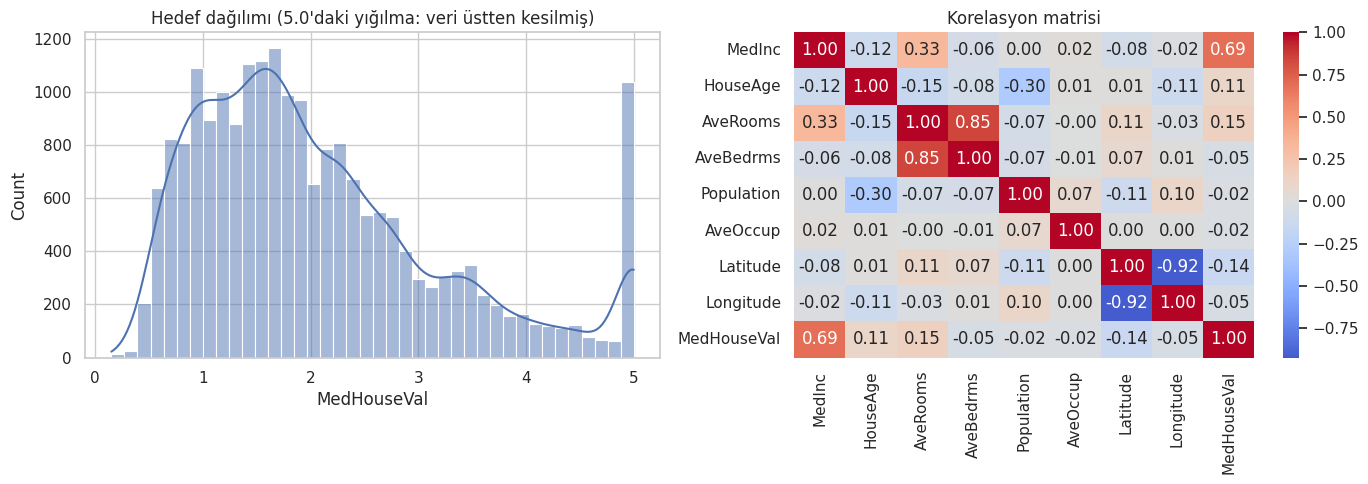

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_ev["MedHouseVal"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Hedef dağılımı (5.0'daki yığılma: veri üstten kesilmiş)")
sns.heatmap(df_ev.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Korelasyon matrisi")
plt.tight_layout()
plt.show()

### Çoklu doğrusal regresyon
Tüm özelliklerle tek bir doğrusal model kuruyoruz: `fiyat = b0 + b1·gelir + b2·evyaşı + …`

In [4]:
X_ev = df_ev.drop(columns="MedHouseVal")
y_ev = df_ev["MedHouseVal"]
X_tr, X_te, y_tr, y_te = train_test_split(X_ev, y_ev, test_size=0.2, random_state=SEED)

dogrusal = LinearRegression().fit(X_tr, y_tr)
tahmin = dogrusal.predict(X_te)

print(f"R²   = {r2_score(y_te, tahmin):.3f}")
print(f"MAE  = {mean_absolute_error(y_te, tahmin):.3f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_te, tahmin)):.3f}")

R²   = 0.576
MAE  = 0.533
RMSE = 0.746


**statsmodels OLS özeti:** sklearn sadece tahmin yapar. statsmodels ise her katsayının **p-değerini** ve güven aralığını da verir.
`P>|t|` sütununda 0.05'ten küçük değerler, o değişkenin anlamlı bir etkisi olduğunu gösterir.

In [5]:
ols = sm.OLS(y_tr, sm.add_constant(X_tr)).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     3261.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        10:14:00   Log-Likelihood:                -17998.
No. Observations:               16512   AIC:                         3.601e+04
Df Residuals:                   16503   BIC:                         3.608e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -37.0233      0.728    -50.835      0.0

### Tahmin ve artık (residual) analizi
- **Sol:** Noktalar kırmızı çizgiye ne kadar yakınsa tahmin o kadar iyi.
- **Orta:** Artıklar (gerçek − tahmin) sıfır etrafında rastgele dağılmalı. Bir desen varsa model bir şeyi kaçırıyor demektir.
- **Sağ:** Artıkların dağılımı kabaca normal olmalı.

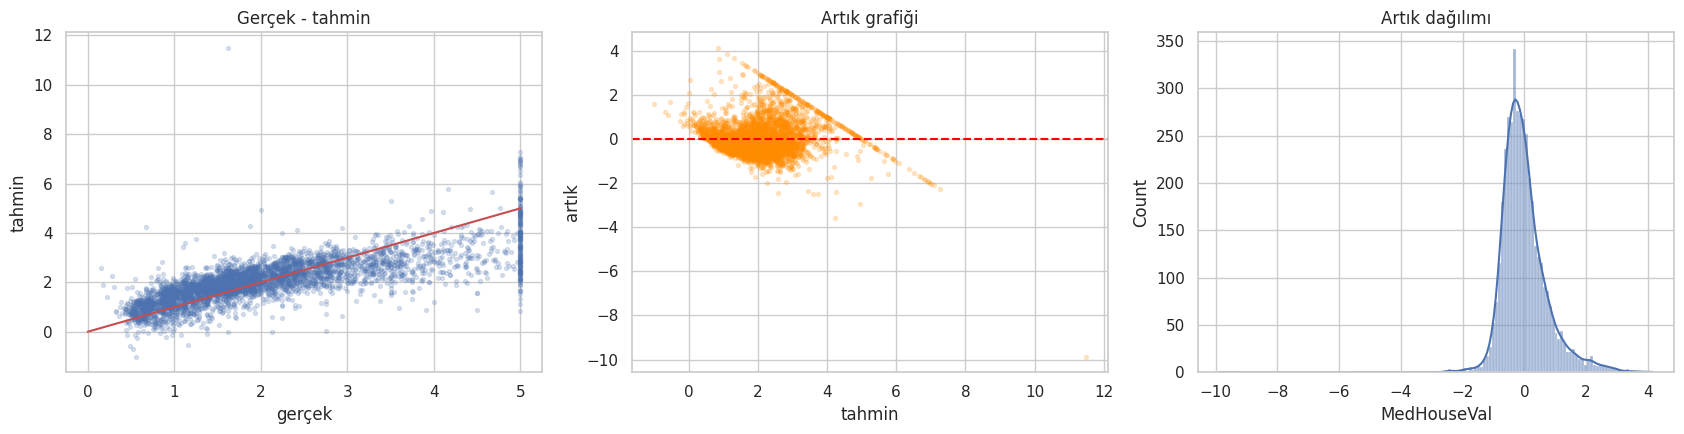

In [6]:
artik = y_te - tahmin
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].scatter(y_te, tahmin, alpha=0.2, s=8)
axes[0].plot([0, 5], [0, 5], "r")
axes[0].set(xlabel="gerçek", ylabel="tahmin", title="Gerçek - tahmin")

axes[1].scatter(tahmin, artik, alpha=0.2, s=8, color="darkorange")
axes[1].axhline(0, color="red", ls="--")
axes[1].set(xlabel="tahmin", ylabel="artık", title="Artık grafiği")

sns.histplot(artik, kde=True, ax=axes[2])
axes[2].set_title("Artık dağılımı")
plt.tight_layout()
plt.show()

### Polinom regresyon
İlişki düz bir çizgi değilse `x², x³` gibi terimler ekleyerek doğruyu eğriye çeviriyoruz.
Önce tek bir değişkenle (medyan gelir) farklı dereceleri görselleştiriyoruz, sonra tüm değişkenlerle 2. dereceyi deniyoruz.

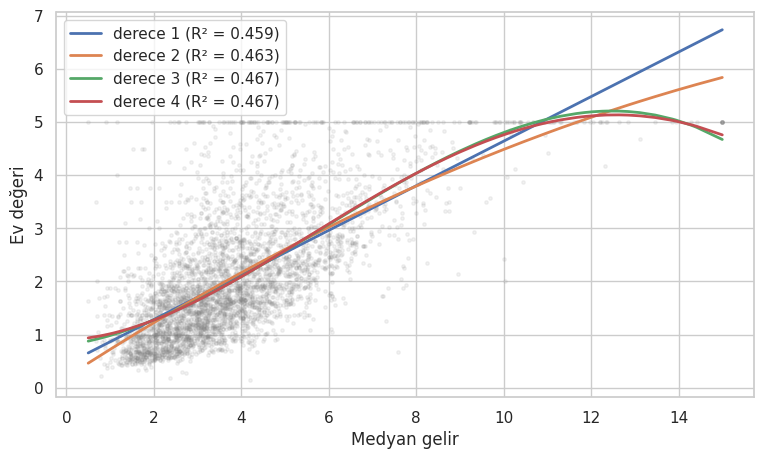

In [7]:
x_tek_tr, x_tek_te = X_tr[["MedInc"]], X_te[["MedInc"]]
sira = np.argsort(x_tek_te["MedInc"].to_numpy())
x_ciz = x_tek_te.iloc[sira]

plt.figure(figsize=(9, 5))
plt.scatter(x_tek_te, y_te, alpha=0.1, s=6, color="gray")
for derece in [1, 2, 3, 4]:
    model = make_pipeline(PolynomialFeatures(derece), LinearRegression()).fit(x_tek_tr, y_tr)
    r2 = r2_score(y_te, model.predict(x_tek_te))
    plt.plot(x_ciz, model.predict(x_ciz), lw=2, label=f"derece {derece} (R² = {r2:.3f})")
plt.xlabel("Medyan gelir")
plt.ylabel("Ev değeri")
plt.legend()
plt.show()

In [8]:
polinom = make_pipeline(PolynomialFeatures(2), StandardScaler(), LinearRegression()).fit(X_tr, y_tr)
print(f"Doğrusal R²           : {r2_score(y_te, tahmin):.3f}")
print(f"2. derece polinom R²  : {r2_score(y_te, polinom.predict(X_te)):.3f}")

Doğrusal R²           : 0.576
2. derece polinom R²  : 0.646


## 2. Sınıflandırma: German Credit
**Ne yapıyoruz?** 1000 kredi başvurusunun bilgilerinden başvurunun **riskli (1)** mi, **iyi (0)** mi olduğunu tahmin ediyoruz.
Veri OpenML'den indiriliyor. Kategorik sütunlar (hesap durumu, kredi amacı…) var.

In [ ]:
kredi = fetch_openml("credit-g", version=1, as_frame=True)
df_k = kredi.frame.copy()
df_k["riskli"] = (df_k["class"] == "bad").astype(int)
df_k = df_k.drop(columns="class")

print(df_k.shape)
print(df_k["riskli"].value_counts(normalize=True).rename({0: "iyi", 1: "riskli"}).round(2))
df_k.head()

**One-hot encoding:** Modeller metin anlayamaz. `get_dummies`, her kategori için 0/1 değerli ayrı bir sütun açar.
`drop_first=True` ile her gruptan bir sütunu atıyoruz, çünkü o bilgi diğer sütunlardan zaten çıkarılabilir.

In [ ]:
kategorik = df_k.select_dtypes(include=["category", "object"]).columns
df_kod = pd.get_dummies(df_k, columns=kategorik, drop_first=True, dtype=int)

X_k = df_kod.drop(columns="riskli")
y_k = df_kod["riskli"]
print("Sütun sayısı:", X_k.shape[1])

Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(X_k, y_k, test_size=0.2, stratify=y_k, random_state=SEED)

olcek = StandardScaler().fit(Xk_tr)
Xk_tr_s = olcek.transform(Xk_tr)
Xk_te_s = olcek.transform(Xk_te)

Bütün modelleri aynı metriklerle ölçmek için bir yardımcı fonksiyon yazıyoruz.
Kredi verisinde **recall** önemli: riskli bir müşteriyi kaçırmak (FN), iyi bir müşteriyi reddetmekten (FP) daha pahalıdır.

In [ ]:
def degerlendir(ad, model, X, y):
    tahmin = model.predict(X)
    if hasattr(model, "decision_function"):
        skor = model.decision_function(X)
    else:
        skor = model.predict_proba(X)[:, 1]
    return {"model": ad,
            "accuracy": accuracy_score(y, tahmin),
            "precision": precision_score(y, tahmin, zero_division=0),
            "recall": recall_score(y, tahmin),
            "f1": f1_score(y, tahmin),
            "roc_auc": roc_auc_score(y, skor)}

### Lojistik regresyon
Her başvuru için 0 ile 1 arasında bir **olasılık** üretir. 0.5'in üstündeki olasılıklar "riskli" olarak etiketlenir.

In [ ]:
lojistik = LogisticRegression(max_iter=1000).fit(Xk_tr_s, yk_tr)

olasilik = lojistik.predict_proba(Xk_te_s)[:, 1]
pd.DataFrame({"gerçek": yk_te.to_numpy()[:8],
              "tahmin": lojistik.predict(Xk_te_s)[:8],
              "riskli olasılığı": olasilik[:8].round(2)})

In [ ]:
ConfusionMatrixDisplay.from_estimator(lojistik, Xk_te_s, yk_te, display_labels=["iyi", "riskli"], cmap="Blues")
plt.title("Lojistik regresyon")
plt.show()
print(classification_report(yk_te, lojistik.predict(Xk_te_s), target_names=["iyi", "riskli"]))

### SVM (Destek Vektör Makinesi)
Sınıflar arasına, iki tarafa da **en geniş boşluğu** bırakan sınırı çizer.
- `kernel="linear"`: düz sınır
- `kernel="rbf"`: eğri sınır
- `C`: hatalara ne kadar tolerans gösterileceği. Büyük C daha az tolerans demek, overfit riski artar.
- `gamma`: rbf sınırının ne kadar kıvrımlı olacağı

In [ ]:
svm_linear = SVC(kernel="linear", C=1.0).fit(Xk_tr_s, yk_tr)
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale").fit(Xk_tr_s, yk_tr)
print("Linear SVM destek vektörü sayısı:", svm_linear.n_support_.sum())

pd.DataFrame([
    degerlendir("Lojistik", lojistik, Xk_te_s, yk_te),
    degerlendir("SVM (linear)", svm_linear, Xk_te_s, yk_te),
    degerlendir("SVM (rbf)", svm_rbf, Xk_te_s, yk_te),
]).set_index("model").round(3)

**GridSearch ile SVM ayarı:** 4 C × 4 gamma = 16 kombinasyon, her biri 5 katlı CV ile deneniyor.
Skor olarak `f1` seçtik, çünkü sınıflar dengesiz (%70 iyi, %30 riskli).

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
svm_arama = GridSearchCV(
    SVC(kernel="rbf"),
    {"C": [0.1, 1, 10, 100], "gamma": [1, 0.1, 0.01, 0.001]},
    cv=cv, scoring="f1", n_jobs=-1,
).fit(Xk_tr_s, yk_tr)

print("En iyi ayar:", svm_arama.best_params_, "· CV f1:", round(svm_arama.best_score_, 3))
svm_best = svm_arama.best_estimator_

In [ ]:
sonuc = pd.DataFrame(svm_arama.cv_results_)
isi = sonuc.pivot_table(index="param_C", columns="param_gamma", values="mean_test_score")
sns.heatmap(isi, annot=True, fmt=".3f", cmap="viridis")
plt.title("C × gamma için CV f1 skoru")
plt.show()

### KNN (K-En Yakın Komşu)
Yeni bir başvuruya en çok benzeyen **k** eski başvuruya bakar ve onların çoğunluğu hangi sınıftaysa onu seçer.
Uzaklık hesabı yaptığı için **ölçekleme şart**. k küçükse model gürültüye duyarlı olur (overfit), k büyükse fazla basitleşir.

In [ ]:
k_degerleri = list(range(1, 32, 2))
f1_ort = [cross_val_score(KNeighborsClassifier(n_neighbors=k), Xk_tr_s, yk_tr, cv=cv, scoring="f1").mean()
          for k in k_degerleri]

plt.plot(k_degerleri, f1_ort, "o-")
plt.xlabel("k (komşu sayısı)")
plt.ylabel("CV f1")
plt.title("KNN: k değerine göre başarı")
plt.show()

In [ ]:
knn_arama = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": k_degerleri, "weights": ["uniform", "distance"], "p": [1, 2]},
    cv=cv, scoring="f1", n_jobs=-1,
).fit(Xk_tr_s, yk_tr)
print("En iyi ayar:", knn_arama.best_params_, "· CV f1:", round(knn_arama.best_score_, 3))
knn_best = knn_arama.best_estimator_

### Karşılaştırma
Üç modelin en iyi hallerini aynı test setinde karşılaştırıyoruz.

In [ ]:
modeller = {"Lojistik": lojistik, "SVM (en iyi)": svm_best, "KNN (en iyi)": knn_best}

pd.DataFrame([degerlendir(ad, m, Xk_te_s, yk_te) for ad, m in modeller.items()]).set_index("model").round(3)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
for ad, m in modeller.items():
    RocCurveDisplay.from_estimator(m, Xk_te_s, yk_te, name=ad, ax=ax)
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("ROC eğrileri")
plt.show()